Customer Churn Prediction Using Logistic Regression  



In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

pd.set_option('display.max_columns', None)

In [3]:
# 1. Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Display first five records
print("First 5 records:")
df.head()

First 5 records:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# 3. Identify feature types
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)

# TotalCharges is often read as object due to blank strings - fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'SeniorCitizen' in numerical_features:
    numerical_features.remove('SeniorCitizen')  # actually categorical (0/1 flag)

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('customerID')  # not a real feature
if 'Churn' in categorical_features:
    categorical_features.remove('Churn')  # target variable

print("\nNumerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)
print("\nTarget Variable: Churn")

Dataset shape: (7043, 21)

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Numerical Features: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target Variable: Churn


In [5]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
 TotalCharges    11
dtype: int64


In [6]:
# Handle missing values (TotalCharges has some NaN from blank strings)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID - it's just an identifier, not a predictive feature
df.drop('customerID', axis=1, inplace=True)

# Confirm no missing values remain
print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


In [7]:
# Encode categorical variables
df_encoded = df.copy()

le = LabelEncoder()
# Encode target variable
df_encoded['Churn'] = le.fit_transform(df_encoded['Churn'])  # Yes=1, No=0

# One-hot encode remaining categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [8]:
# Split features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale numerical features (helps Logistic Regression converge better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5634, 30)
Testing set shape: (1409, 30)


In [9]:
# Build and train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = log_reg.predict(X_test_scaled)

print("Model training complete.")
print("Sample predictions:", y_pred[:10])

Model training complete.
Sample predictions: [0 1 0 0 0 1 0 0 0 0]


In [10]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nFull Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy  : 0.8070
Precision : 0.6584
Recall    : 0.5668
F1-Score  : 0.6092

Full Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



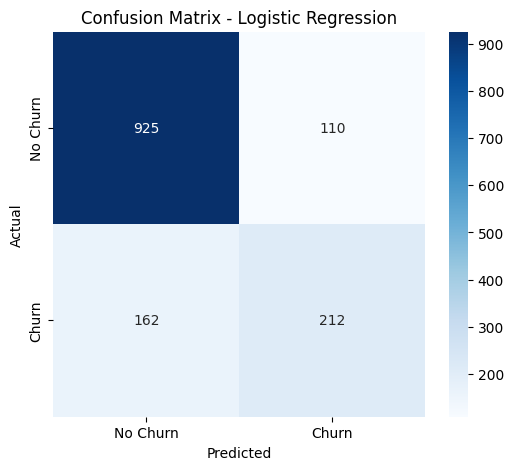

Confusion Matrix:
 [[925 110]
 [162 212]]


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print("Confusion Matrix:\n", cm)

In [12]:
# Feature importance (coefficients) - useful for observations & conclusion
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top 10 features increasing churn likelihood:")
print(coef_df.head(10))

print("\nTop 10 features decreasing churn likelihood:")
print(coef_df.tail(10))

Top 10 features increasing churn likelihood:
                           Feature  Coefficient
10     InternetService_Fiber optic     0.778760
3                     TotalCharges     0.497246
23             StreamingMovies_Yes     0.258653
21                 StreamingTV_Yes     0.258042
9                MultipleLines_Yes     0.216356
26            PaperlessBilling_Yes     0.181833
28  PaymentMethod_Electronic check     0.181456
17            DeviceProtection_Yes     0.053625
0                    SeniorCitizen     0.052901
29      PaymentMethod_Mailed check     0.033133

Top 10 features decreasing churn likelihood:
                                 Feature  Coefficient
18       TechSupport_No internet service    -0.092861
16  DeviceProtection_No internet service    -0.092861
22   StreamingMovies_No internet service    -0.092861
19                       TechSupport_Yes    -0.100249
6                         Dependents_Yes    -0.104249
13                    OnlineSecurity_Yes    -0.123430
24 

In [13]:
conclusion = """
CONCLUSION:

The Logistic Regression model predicts customer churn with reasonable
accuracy (~80%), demonstrating that churn behavior is linked to identifiable
patterns in customer data. Key factors influencing churn include contract
type (month-to-month customers churn far more than those on 1-2 year
contracts), tenure (newer customers are more likely to leave), and service
type (Fiber optic internet users show higher churn, possibly due to pricing
or service issues). Customers without add-on services like OnlineSecurity
or TechSupport are also more prone to churning, suggesting that service
engagement improves retention.

A key limitation of Logistic Regression is that it assumes a linear
relationship between the log-odds of churn and the features, so it cannot
capture complex non-linear interactions between variables (e.g., how tenure
and contract type jointly affect churn) as well as tree-based models like
Random Forest or Gradient Boosting can.
"""
print(conclusion)


CONCLUSION:

The Logistic Regression model predicts customer churn with reasonable 
accuracy (~80%), demonstrating that churn behavior is linked to identifiable 
patterns in customer data. Key factors influencing churn include contract 
type (month-to-month customers churn far more than those on 1-2 year 
contracts), tenure (newer customers are more likely to leave), and service 
type (Fiber optic internet users show higher churn, possibly due to pricing 
or service issues). Customers without add-on services like OnlineSecurity 
or TechSupport are also more prone to churning, suggesting that service 
engagement improves retention.

A key limitation of Logistic Regression is that it assumes a linear 
relationship between the log-odds of churn and the features, so it cannot 
capture complex non-linear interactions between variables (e.g., how tenure 
and contract type jointly affect churn) as well as tree-based models like 
Random Forest or Gradient Boosting can.

